<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/ADA_Boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np

In [41]:
df = pd.read_csv("/content/census-income.csv")

In [42]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Unnamed: 14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [43]:
df = df.rename(columns={"Unnamed: 14":"annual_income"})

In [44]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [45]:
df.replace([" ","?"],np.nan,inplace=True)

In [46]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  annual_income   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [48]:
df.isnull().sum().sum()

np.int64(4262)

In [49]:
(4262/32561)*100

13.08927858481005

In [50]:
for i in df.columns:
  if(df[i].dtype == "object"):
    df[i] = df[i].fillna(df[i].mode()[0])


In [51]:
df.isnull().sum().sum()

np.int64(0)

In [52]:
df.duplicated().sum()

np.int64(24)

In [53]:
df.drop_duplicates(inplace=True)

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
import matplotlib.pyplot as plt


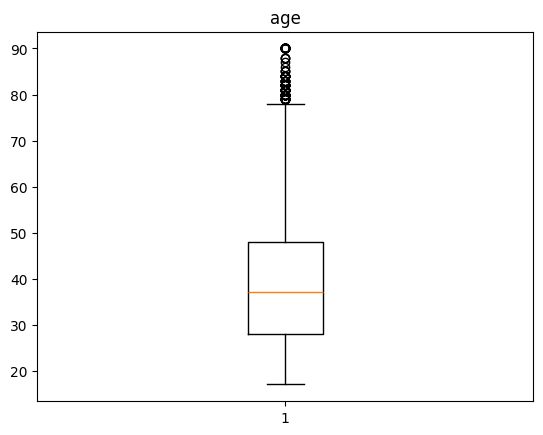

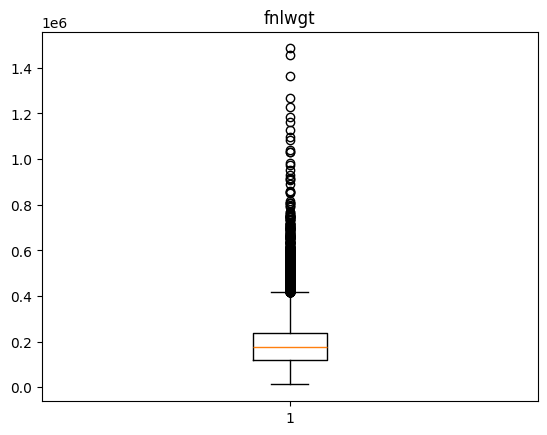

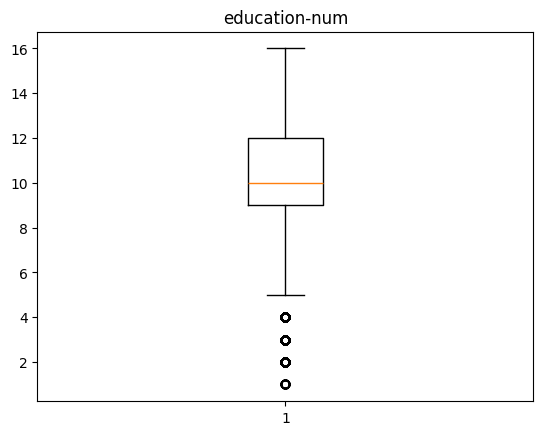

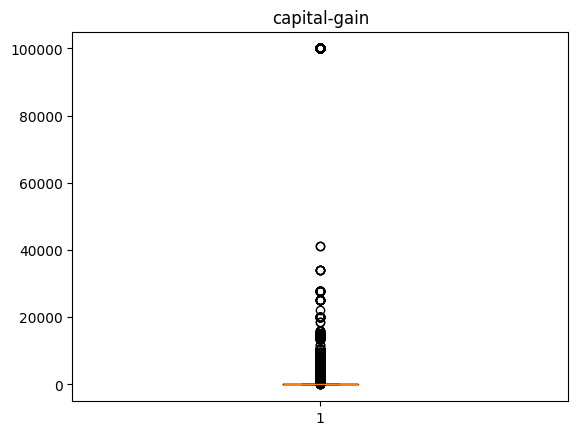

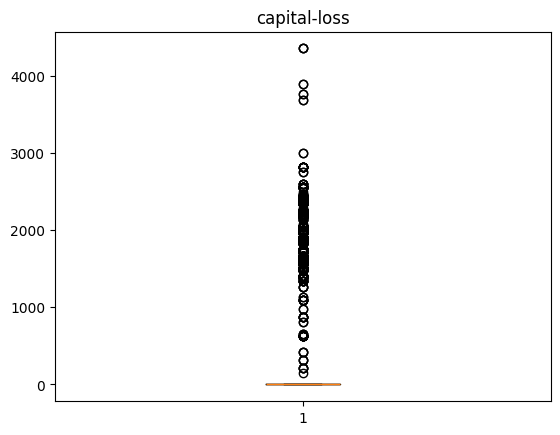

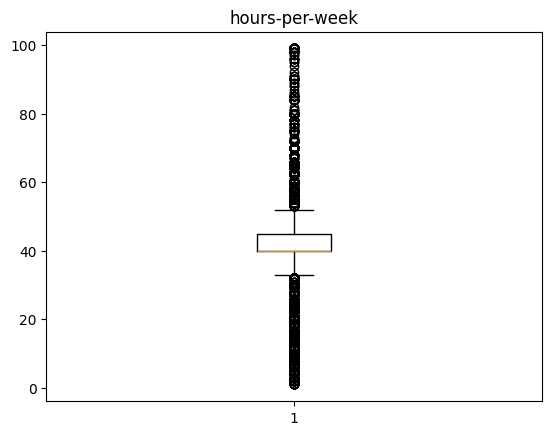

In [56]:
for i in df.columns:
  if(df[i].dtype != "object"):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [57]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'annual_income'],
      dtype='object')

In [58]:
col = ['fnlwgt','hours-per-week']

In [59]:
import seaborn as sns

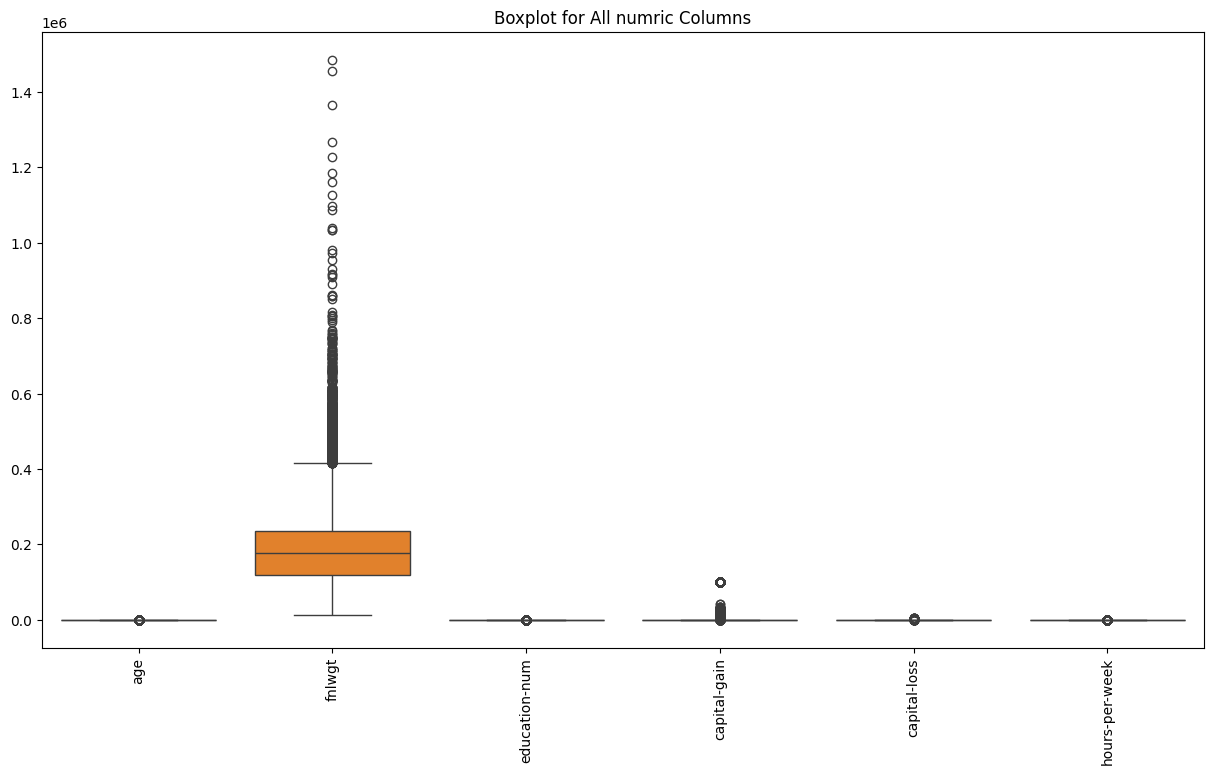

In [60]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df.select_dtypes(include="number"))
plt.xticks(rotation=90)
plt.title("Boxplot for All numric Columns")
plt.show()

In [61]:
for i in col:
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  IQR =Q3-Q1
  LB = Q1-1.5*IQR
  UB = Q3+1.5*IQR

  df = df[(df[i]>=LB) & (df[i]<=UB)]

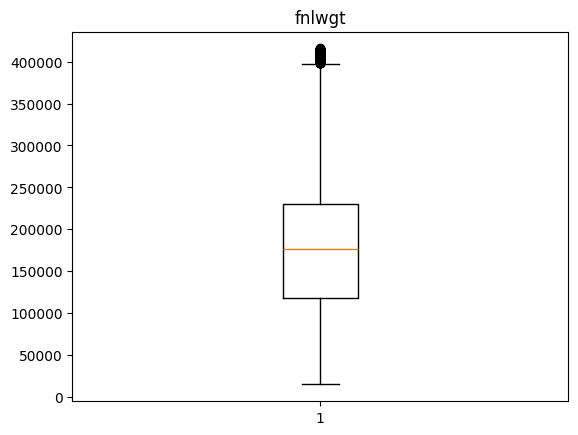

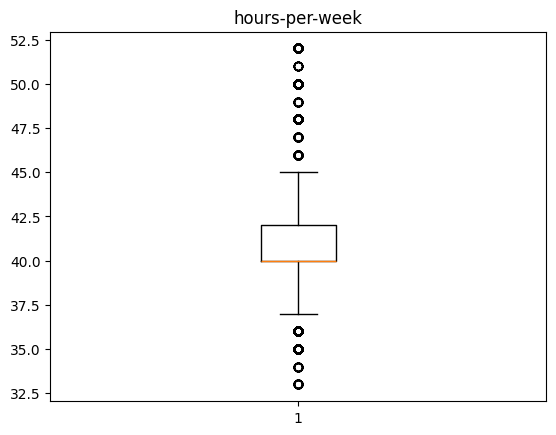

In [62]:
for i in col:
  plt.boxplot(df[i])
  plt.title(i)
  plt.show()

In [63]:
from sklearn.ensemble import AdaBoostClassifier

In [64]:
from sklearn.preprocessing import LabelEncoder

In [65]:
le = LabelEncoder()
for i in df.columns:
  if(df[i].dtype == "object"):
    df[i] = le.fit_transform(df[i])

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22784 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             22784 non-null  int64
 1   workclass       22784 non-null  int64
 2   fnlwgt          22784 non-null  int64
 3   education       22784 non-null  int64
 4   education-num   22784 non-null  int64
 5   marital-status  22784 non-null  int64
 6   occupation      22784 non-null  int64
 7   relationship    22784 non-null  int64
 8   race            22784 non-null  int64
 9   sex             22784 non-null  int64
 10  capital-gain    22784 non-null  int64
 11  capital-loss    22784 non-null  int64
 12  hours-per-week  22784 non-null  int64
 13  native-country  22784 non-null  int64
 14  annual_income   22784 non-null  int64
dtypes: int64(15)
memory usage: 2.8 MB


In [67]:
df['annual_income'].value_counts()

,count
annual_income,
0,16946
1,5838


In [69]:
x = df.drop(columns="annual_income")
y = df["annual_income"]

In [70]:
x

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4
5,37,3,284582,12,14,2,3,5,4,0,0,0,40,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,22,3,310152,15,10,4,10,1,4,1,0,0,40,38
32556,27,3,257302,7,12,2,12,5,4,0,0,0,38,38
32557,40,3,154374,11,9,2,6,0,4,1,0,0,40,38
32558,58,3,151910,11,9,6,0,4,4,0,0,0,40,38


In [71]:
y

,annual_income
0,0
2,0
3,0
4,0
5,0
...,...
32555,0
32556,0
32557,1
32558,0


In [72]:
from sklearn.model_selection import train_test_split

In [73]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [74]:
x_train.shape


(18227, 14)

In [75]:
y_train.shape

(18227,)

In [76]:
# 1.Logical Regression

from sklearn.linear_model import LogisticRegression

In [77]:
model1 = LogisticRegression()

In [78]:
model1.fit(x_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [79]:
y_pred = model1.predict(x_test)

In [80]:
from sklearn.metrics import *

In [81]:
accuracy_score(y_test,y_pred)

0.7812157120912882

**2.Decision Tree**

In [83]:
from sklearn.tree import DecisionTreeClassifier

In [84]:
model2 = DecisionTreeClassifier()

In [85]:
model2.fit(x_train,y_train)

DecisionTreeClassifier()

In [86]:
y_pred1 = model2.predict(x_test)

In [87]:
y_pred1

array([0, 1, 0, ..., 0, 0, 0])

In [88]:
accuracy_score(y_test,y_pred1)

0.7948211542681589

**3.Random Forest**

In [89]:
from sklearn.ensemble import RandomForestClassifier

In [90]:
model3 = RandomForestClassifier()

In [91]:
model3.fit(x_train,y_train)

RandomForestClassifier()

In [92]:
y_pred3 = model3.predict(x_test)

In [93]:
accuracy_score(y_pred3,y_test)

0.8433179723502304

**ADA Boost**

In [94]:
from sklearn.ensemble import AdaBoostClassifier

In [96]:
ada_model=AdaBoostClassifier()

In [98]:
ada_model.fit(x_train,y_train)

AdaBoostClassifier()

In [99]:
ada_pred = ada_model.predict(x_test)

In [100]:
accuracy_score(ada_pred,y_test)

0.8461707263550582

In [101]:
model5 = AdaBoostClassifier(n_estimators=100,learning_rate=1,random_state=42)

In [102]:
model5 = model5.fit(x_train,y_train)

In [103]:
model5.fit(x_train,y_train)

AdaBoostClassifier(learning_rate=1, n_estimators=100, random_state=42)

In [104]:
y_pred5 = model5.predict(x_test)

In [105]:
accuracy_score(y_pred5,y_test)

0.8468290542023261